In [3]:
#importing libraries
import math
import networkx as nx
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import requests
import json
from datetime import datetime, timedelta
import gzip
import os
import time

In [4]:
# loading data set
DATA_PATH = "filtered_data_set(1).csv" 
df = pd.read_csv(DATA_PATH,)
df


,Unnamed: 0,ticker,participant_timestamp,ask_price,bid_price,open,high,low,close,volume
0,0,C:ZAREUR,1780358399999000000,0,0,0.052708,0.052993,0.052052,0.052717,123113
1,1,C:SEKGBP,1780358399999000000,0,0,0.080323,0.080415,0.079053,0.079758,42306
2,2,C:CADHKD,1780358399999000000,0,0,5.678920,5.679485,5.655318,5.662163,121176
3,3,C:AUDHKD,1780358399999000000,0,0,5.625950,5.635160,5.589400,5.614730,139889
4,4,C:ZARAED,1780358399999000000,0,0,0.225884,0.226695,0.214094,0.225270,241088
...,...,...,...,...,...,...,...,...,...,...
29629,29629,C:USDYER,1782950399999000000,0,0,238.250000,238.250000,238.250000,238.250000,3
29630,29630,C:XPFUSD,1782950399999000000,0,0,0.009497,0.009497,0.009479,0.009479,3
29631,29631,C:YERUSD,1782950399999000000,0,0,0.004186,0.004186,0.004185,0.004185,3
29632,29632,C:USDSDG,1782950399999000000,0,0,597.000000,598.000000,597.000000,598.000000,3


In [10]:
# Construct a directed, weighted graph in which the nodes
# are currencies and the edge weights are exchange rates.

graph = {}

for _, row in df.iterrows():
    ticker = row["ticker"]

    currency1 = ticker[2:5]      # Base currency
    currency2 = ticker[5:8]      # Quote currency
    rate = row["open"]

    # Ensure both currencies exist as nodes
    graph.setdefault(currency1, {})
    graph.setdefault(currency2, {})

    # Add directed edge
    graph[currency1][currency2] = rate

print(f"Constructed graph with {len(graph)} currencies")

# Verify graph integrity
sources = set(graph.keys())
targets = set()

for rates in graph.values():
    targets.update(rates.keys())

missing = targets - sources

if missing:
    print("Missing source nodes:", missing)
else:
    print("✓ Graph is valid.")

for curr, rates in graph.items():
    print(f"{curr}: {list(rates.keys())}")

Constructed graph with 129 currencies
✓ Graph is valid.
ZAR: ['EUR', 'AED', 'TWD', 'SEK', 'DKK', 'JPY', 'PHP', 'NOK', 'NGN', 'PKR', 'HUF', 'TRY', 'CZK', 'HKD', 'CHF', 'BWP', 'MXN', 'EGP', 'USD', 'GBP', 'CAD', 'SGD', 'RUB', 'RON', 'CNY', 'THB', 'AUD', 'PLN', 'NZD', 'KRW', 'BRL', 'MYR', 'IDR', 'INR', 'ILS', 'ARS', 'MAD', 'RWF', 'KES', 'NAD', 'SZL', 'UGX', 'COP', 'MWK', 'GHS', 'TND']
EUR: ['SEK', 'TWD', 'CAD', 'ZAR', 'AUD', 'CZK', 'MXN', 'NZD', 'HUF', 'HKD', 'CHF', 'USD', 'NOK', 'GBP', 'DKK', 'PLN', 'SGD', 'JPY', 'TRY', 'CNH', 'RON', 'CNY', 'BRL', 'ILS', 'ARS', 'KRW', 'KWD', 'INR', 'MUR', 'JOD', 'FJD', 'THB', 'EGP', 'SCR', 'PHP', 'OMR', 'DZD', 'RSD', 'AED', 'RUB', 'MKD', 'BZD', 'TTD', 'KZT', 'BDT', 'UZS', 'MDL', 'CLP', 'DOP', 'PGK', 'DJF', 'KHR', 'GHS', 'NGN', 'NAD', 'MOP', 'MGA', 'BIF', 'UAH', 'BBD', 'MAD', 'GNF', 'LYD', 'BHD', 'VND', 'BMD', 'COP', 'MWK', 'CUP', 'NIO', 'KES', 'ISK', 'RWF', 'QAR', 'BWP', 'HNL', 'IDR', 'MYR', 'PAB', 'BOB', 'ETB', 'LAK', 'TZS', 'BND', 'SVC', 'UGX', 'LKR', '

In [12]:
# Simple functions to help perform arbitrage.

def graph_exchange_to_log(graph: dict[str, dict[str, float]]) -> dict[str, dict[str, float]]:
    log_graph = dict()
    for currency in graph:
        log_graph[currency] = {c: -math.log(w) for c, w in graph[currency].items()}
    return log_graph

def bellman_ford(graph: dict[str, dict[str, float]]) -> list:
    # Convert exchange rates to negative log weights
    graph = graph_exchange_to_log(graph)

    # ------------------------------------------------------------------
    # FIX: Ensure every destination currency exists as a graph node
    # ------------------------------------------------------------------
    all_nodes = set(graph.keys())

    for edges in graph.values():
        all_nodes.update(edges.keys())

    for node in all_nodes:
        graph.setdefault(node, {})
    # ------------------------------------------------------------------

    # Add sentinel source
    graph["\0"] = {c: 0 for c in all_nodes}

    # Initialize
    distance = {c: float("inf") for c in graph}
    predecessor = {c: None for c in graph}
    distance["\0"] = 0

    # Bellman-Ford relaxation
    for _ in range(len(graph) - 1):
        updated = False
        for c1 in graph:
            for c2, weight in graph[c1].items():
                if distance[c1] + weight < distance[c2]:
                    distance[c2] = distance[c1] + weight
                    predecessor[c2] = c1
                    updated = True
        if not updated:
            break

    # Find negative cycles
    negative_cycles = []
    processed_nodes = set()

    for c1 in graph:
        for c2, weight in graph[c1].items():
            if distance[c1] + weight < distance[c2] and c2 not in processed_nodes:

                current = c2

                # Move inside the cycle
                for _ in range(len(graph)):
                    current = predecessor[current]

                if current is None:
                    continue

                cycle = []
                start = current

                while True:
                    cycle.append(current)
                    processed_nodes.add(current)
                    current = predecessor[current]
                    if current == start or current is None:
                        break

                cycle.reverse()
                negative_cycles.append(cycle)

    return negative_cycles


# print("Missing source nodes:", targets - sources)
result = bellman_ford(graph)
if result:
    print(f"Found {len(result)} negative cycle(s):")
    for i, cycle in enumerate(result, 1):
        print(f"Cycle {i}: {' -> '.join(cycle)} -> {cycle[0]}")
else:
    print("No negative cycles found")

Found 481 negative cycle(s):
Cycle 1: CNY -> KRW -> RUB -> EUR -> BWP -> GBP -> MYR -> CNY
Cycle 2: EUR -> BWP -> GBP -> MYR -> CNY -> KRW -> RUB -> EUR
Cycle 3: MYR -> CNY -> KRW -> RUB -> EUR -> BWP -> GBP -> MYR
Cycle 4: MYR -> CNY -> KRW -> RUB -> EUR -> BWP -> GBP -> MYR
Cycle 5: CNY -> KRW -> RUB -> EUR -> BWP -> GBP -> MYR -> CNY
Cycle 6: CNY -> KRW -> RUB -> EUR -> BWP -> GBP -> MYR -> CNY
Cycle 7: EUR -> BWP -> GBP -> MYR -> CNY -> KRW -> RUB -> EUR
Cycle 8: CNY -> KRW -> RUB -> EUR -> BWP -> GBP -> MYR -> CNY
Cycle 9: EUR -> BWP -> GBP -> MYR -> CNY -> KRW -> RUB -> EUR
Cycle 10: KRW -> RUB -> EUR -> BWP -> GBP -> MYR -> CNY -> KRW
Cycle 11: KRW -> RUB -> EUR -> BWP -> GBP -> MYR -> CNY -> KRW
Cycle 12: CNY -> KRW -> RUB -> EUR -> BWP -> GBP -> MYR -> CNY
Cycle 13: EUR -> BWP -> GBP -> MYR -> CNY -> KRW -> RUB -> EUR
Cycle 14: CNY -> KRW -> RUB -> EUR -> BWP -> GBP -> MYR -> CNY
Cycle 15: CNY -> KRW -> RUB -> EUR -> BWP -> GBP -> MYR -> CNY
Cycle 16: CNY -> KRW -> RUB -> EUR 

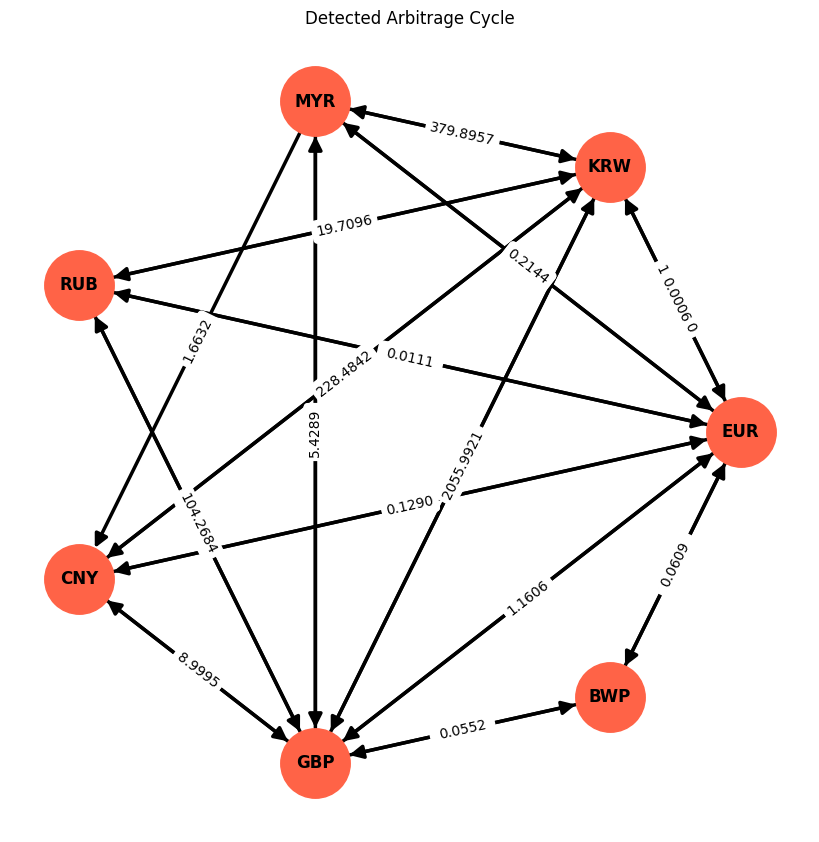

In [ ]:


####################################################

cycle = result[0]              # first arbitrage cycle

H = G.subgraph(cycle).copy()

pos = nx.circular_layout(H)

plt.figure(figsize=(8,8))

nx.draw(
    H,
    pos,
    with_labels=True,
    node_size=2500,
    node_color="tomato",
    font_size=12,
    font_weight="bold",
    width=2.5,
    arrowsize=20,
)

edge_labels = {(u, v): f"{d['weight']:.4f}" for u, v, d in H.edges(data=True)}
nx.draw_networkx_edge_labels(H, pos, edge_labels=edge_labels)

plt.title("Detected Arbitrage Cycle")
plt.savefig("graph.png", dpi=300, bbox_inches='tight')
plt.axis("off")
plt.show()